# **Tech-News-Automation-Dashboard**

In [7]:
!pip install requests beautifulsoup4 pandas matplotlib openpyxl -q

import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from datetime import datetime

In [9]:
def scrape_news():
    print("Scraping Hacker News...")
    headers = {'User-Agent': 'Mozilla/5.0'}

    # Both pages!
    urls = [
        'https://news.ycombinator.com',
        'https://news.ycombinator.com/?p=2'
    ]

    headlines = []
    rank = 1

    for url in urls:
        response = requests.get(url, headers=headers)
        soup = BeautifulSoup(response.text, 'html.parser')

        items  = soup.find_all('span', class_='titleline')
        scores = soup.find_all('span', class_='score')

        for i, item in enumerate(items):
            headlines.append({
                'rank'      : rank,
                'title'     : item.get_text(),
                'votes'     : int(scores[i].get_text().split()[0]) if i < len(scores) else 0,
                'scraped_at': datetime.now().strftime('%Y-%m-%d %H:%M')
            })
            rank += 1

    print(f"Found {len(headlines)} headlines from 2 pages!")
    return headlines

headlines = scrape_news()

Scraping Hacker News...
Found 60 headlines from 2 pages!


In [10]:
POSITIVE = ['launch', 'new', 'best', 'win', 'growth', 'success',
            'open', 'free', 'fast', 'better', 'amazing', 'top']
NEGATIVE = ['hack', 'breach', 'fail', 'down', 'bug', 'crash',
            'leak', 'scam', 'ban', 'risk', 'problem', 'slow']

def get_sentiment(title):
    title_lower = title.lower()
    pos = sum(1 for w in POSITIVE if w in title_lower)
    neg = sum(1 for w in NEGATIVE if w in title_lower)
    if pos > neg:   return 'Positive'
    elif neg > pos: return 'Negative'
    else:           return 'Neutral'

# Process data
df = pd.DataFrame(headlines)
df['sentiment']    = df['title'].apply(get_sentiment)
df['title_length'] = df['title'].apply(len)
df = df.sort_values('votes', ascending=False)

print(df[['rank', 'title', 'votes', 'sentiment']].to_string())
print("\nData processed! ")

    rank                                                                                                 title  votes sentiment
53    54                                                          I'm Tired of Talking to AI (orchidfiles.com)   1870   Neutral
10    11                                                                    Can we have the day off? (mlsu.io)    812   Neutral
14    15                                             A New Typst Template for Pandoc (2025) (imaginarytext.ca)    736  Positive
2      3                        I think Anthropic and OpenAI have found product-market fit (simonwillison.net)    732  Positive
27    28         Stress disrupts hippocampal integration of overlapping events, memory inference (science.org)    689   Neutral
0      1                                     YouTube to automatically label AI-generated videos (blog.youtube)    664   Neutral
34    35                                 Tech CEOs are apparently suffering from AI psychosis (techcrunc

In [11]:
filename = f"news_{datetime.now().strftime('%Y%m%d_%H%M')}.xlsx"
df.to_excel(filename, index=False)
print(f"Saved: {filename}")

Saved: news_20260528_0516.xlsx


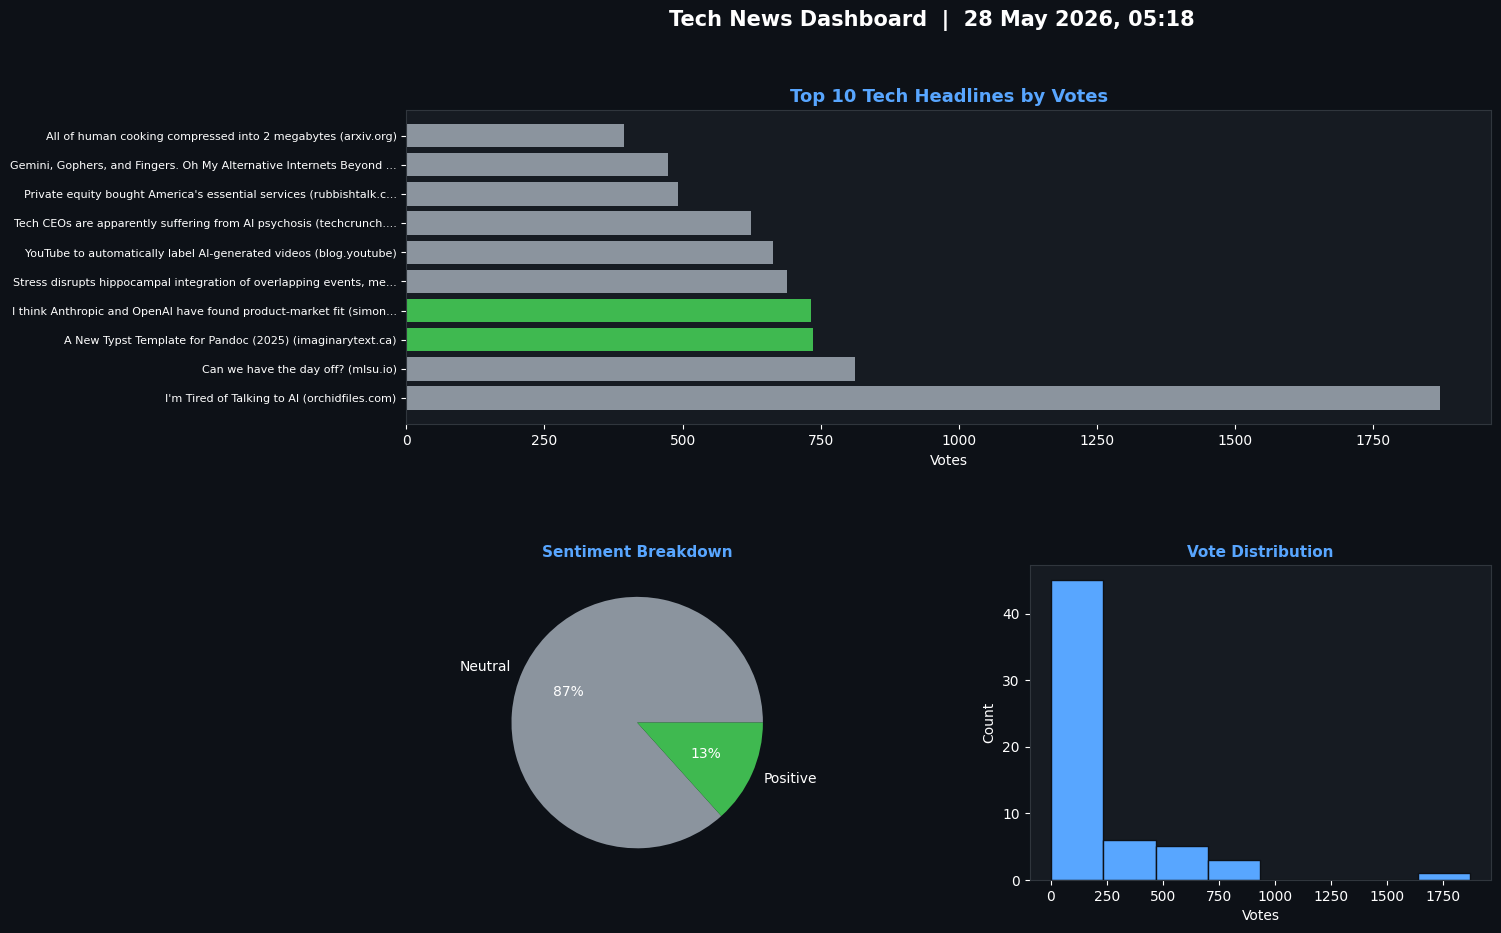

In [13]:
fig = plt.figure(figsize=(14, 10))
fig.patch.set_facecolor('#0D1117')
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

# Chart 1 — Top 10 headlines bar chart
ax1 = fig.add_subplot(gs[0, :])
ax1.set_facecolor('#161B22')
top10  = df.head(10)
colors = ['#3FB950' if s=='Positive' else '#F85149' if s=='Negative'
          else '#8B949E' for s in top10['sentiment']]
ax1.barh(range(len(top10)), top10['votes'], color=colors)
ax1.set_yticks(range(len(top10)))
ax1.set_yticklabels([t[:65]+'...' if len(t)>65 else t
                     for t in top10['title']], fontsize=8, color='white')
ax1.set_xlabel('Votes', color='white')
ax1.set_title('Top 10 Tech Headlines by Votes', color='#58A6FF',
              fontsize=13, fontweight='bold')
ax1.tick_params(colors='white')
ax1.spines[['top','right','left','bottom']].set_color('#30363D')

# Chart 2 — Sentiment pie chart
ax2 = fig.add_subplot(gs[1, 0])
ax2.set_facecolor('#161B22')
counts     = df['sentiment'].value_counts()
pie_colors = {'Positive':'#3FB950','Negative':'#F85149','Neutral':'#8B949E'}
ax2.pie(counts.values, labels=counts.index, autopct='%1.0f%%',
        colors=[pie_colors.get(k,'gray') for k in counts.index],
        textprops={'color':'white', 'fontsize':10})
ax2.set_title('Sentiment Breakdown', color='#58A6FF',
              fontsize=11, fontweight='bold')

# Chart 3 — Vote distribution
ax3 = fig.add_subplot(gs[1, 1])
ax3.set_facecolor('#161B22')
ax3.hist(df['votes'], bins=8, color='#58A6FF', edgecolor='#0D1117')
ax3.set_xlabel('Votes', color='white')
ax3.set_ylabel('Count',  color='white')
ax3.set_title('Vote Distribution', color='#58A6FF',
              fontsize=11, fontweight='bold')
ax3.tick_params(colors='white')
ax3.spines[['top','right','left','bottom']].set_color('#30363D')

# Title
fig.suptitle(f'Tech News Dashboard  |  {datetime.now().strftime("%d %b %Y, %H:%M")}',
             color='white', fontsize=15, fontweight='bold')

plt.savefig('dashboard.png', dpi=150, bbox_inches='tight', facecolor='#0D1117')
plt.show()